Зареждане на данните

In [54]:
import pandas as pd

# Зареждане на данните за червено вино от качения файл
red_wine = pd.read_csv('winequality-red.csv', delimiter=';')

# Зареждане на данните за бяло вино от качения файл
white_wine = pd.read_csv('winequality-white.csv', delimiter=';')

# Добавяне на нова колона за цвета на виното
red_wine['color'] = 'red'
white_wine['color'] = 'white'

# Обединяване на данните за червено и бяло вино
wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

wine_data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Визуализация и анализ на взаимовръзките

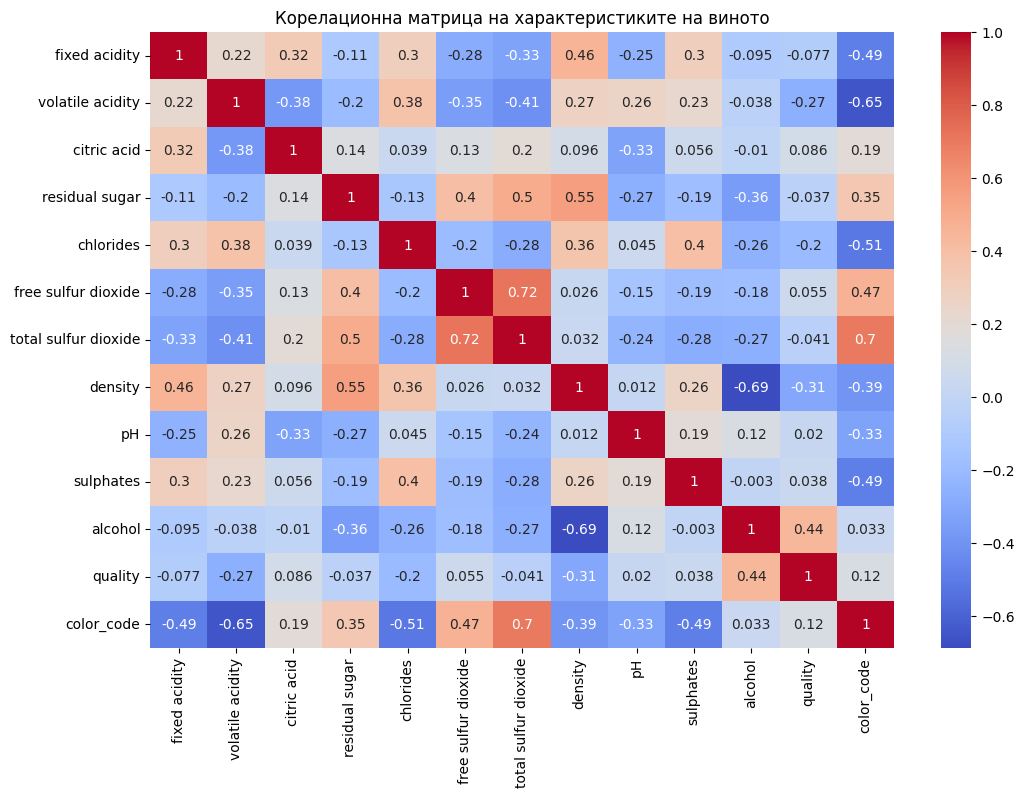

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Преобразуване на колоната за цвят в числени стойности
wine_data['color_code'] = wine_data['color'].map({'red': 0, 'white': 1})

# Премахване на текстовата колона 'color' за корелационната матрица
correlation_matrix = wine_data.drop(columns=['color']).corr()

# Визуализация на корелационната матрица
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корелационна матрица на характеристиките на виното')
plt.show()


Разпределение на качеството на виното

C:\Users\Owner\AppData\Local\Temp\ipykernel_28060\2684681933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=wine_data, palette='viridis')


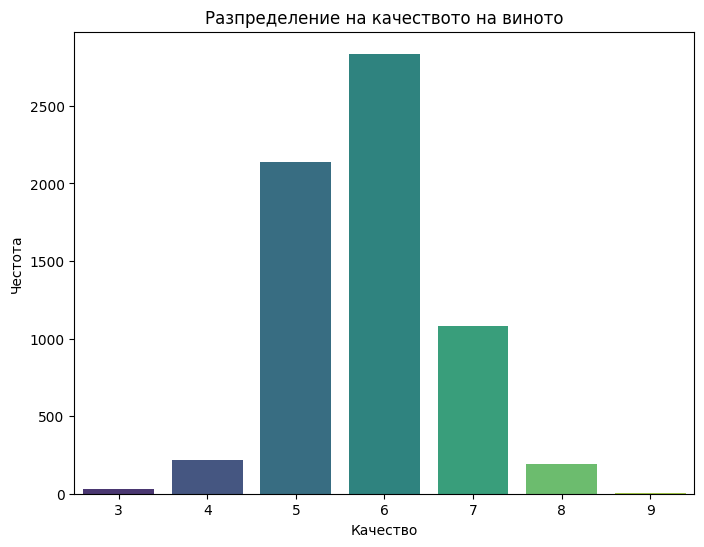

In [56]:
# Разпределение на качеството на виното
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=wine_data, palette='viridis')
plt.title('Разпределение на качеството на виното')
plt.xlabel('Качество')
plt.ylabel('Честота')
plt.show()

Задача 1 за Класификация според качеството на виното

1.1. Класификация с Random Forest

За 2 класа, където до 6 е лошо качество и над 7 е добро

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

wine_data['quality_label'] = wine_data['quality'].apply(lambda x: 'good' if x >= 7 else 'bad')

# Разделяне на характеристиките и целевата променлива
X = wine_data.drop(columns=["quality", 'color', 'quality_label'])
y = wine_data["quality_label"]

# Разделяне на данните на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Създаване на модел на Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Прогнозиране на качеството на виното
y_pred_rf = model_rf.predict(X_test)

# Оценка на точността
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Точност на Random Forest модела: {accuracy_rf:.2f}")


Точност на Random Forest модела: 0.89


За 3 класа, където до 5 е лошо качество, до 7 е средно и над 7 е добро

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)
# wine_data = wine_data.sample(frac=1, random_state=42)

# Добавяне на класификационна маркерна колона
wine_data['quality_label'] = pd.cut(wine_data['quality'], bins=[0, 5, 7, 10], labels=['low', 'medium', 'high'])

# Разделяне на характеристиките и целевата променлива
X = wine_data.drop(columns=["color", "quality", 'quality_label'])
y = wine_data["quality_label"]

# Разделяне на данните на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Създаване на модел на Random Forest за класификация
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучение на модела
model_rf.fit(X_train, y_train)

# Прогнозиране на качеството на виното
y_pred_rf = model_rf.predict(X_test)

# Оценка на точността
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Точност на Random Forest модела: {accuracy_rf:.2f}")

# Извеждане на отчет за класификацията
# print(classification_report(y_test, y_pred_rf))


Точност на Random Forest модела: 0.80


1.2 Класификация с Невронна мрежа

За 2 класа, където до 6 е лошо качество и над 7 е добро

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)
# wine_data = wine_data.sample(frac=1, random_state=42)

# Преобразуване на качеството на вино в бинарна променлива (добро/лошо)
wine_data['quality_label'] = np.where(wine_data['quality'] >= 7, 1, 0)

# Разделяне на характеристиките и целевата променлива
X = wine_data.drop(columns=["quality", "quality_label", 'color'])
y = wine_data["quality_label"]

# Скалиране на данните
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяне на данните на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

# Създаване на модел с невронна мрежа
model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Компилиране на модела
model_nn.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Обучение на модела
history = model_nn.fit(X_train, y_train, epochs=400, batch_size=32, validation_split=0.2, verbose=1)

# Прогнозиране на данните за тест
y_pred_nn = (model_nn.predict(X_test) > 0.5).astype("int32")

# Оценка на точността
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"Точност на невронна мрежа модела: {accuracy_nn:.2f}")

# Извеждане на отчет за класификацията
print(classification_report(y_test, y_pred_nn))



Epoch 1/400


c:\Users\Owner\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7845 - loss: 0.4925 - val_accuracy: 0.8282 - val_loss: 0.3951
Epoch 2/400
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8028 - loss: 0.4252 - val_accuracy: 0.8299 - val_loss: 0.3839
Epoch 3/400
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8239 - loss: 0.3895 - val_accuracy: 0.8299 - val_loss: 0.3707
Epoch 4/400
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8214 - loss: 0.3816 - val_accuracy: 0.8308 - val_loss: 0.3666
Epoch 5/400
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8130 - loss: 0.3918 - val_accuracy: 0.8325 - val_loss: 0.3622
Epoch 6/400
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8166 - loss: 0.3858 - val_accuracy: 0.8308 - val_loss: 0.3615
Epoch 7/400
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8213 - loss: 0.3881 - val_accuracy: 0.8265 - val_loss: 0.3565
Epoch 8/400
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8226 - loss: 0.3804 - val_accuracy: 0.8231

Код за визуализация на обучението

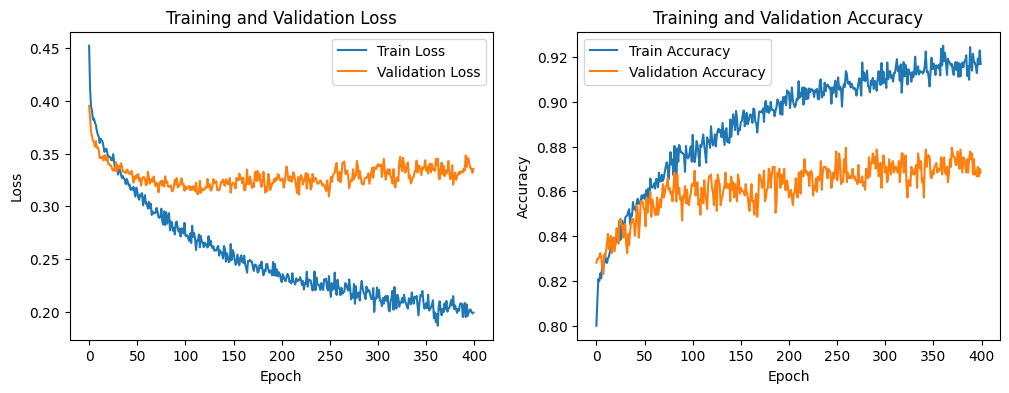

In [60]:
import matplotlib.pyplot as plt

# Визуализация на процеса на обучение
plt.figure(figsize=(12, 4))

# Загуба
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Точност
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()


За 3 класа, където до 5 е лошо качество, до 7 е средно и над 7 е добро

In [61]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Създаване на колоната 'quality_label' на база на 'quality'
wine_data['quality_label'] = pd.cut(wine_data['quality'], bins=[0, 5, 7, 10], labels=['low', 'medium', 'high'])

# Подготовка на данните
X = wine_data.drop(['quality', 'quality_label', 'color'], axis=1)
y = wine_data['quality_label']

# Кодиране на категориалните данни в числови стойности
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Скалиране на данните
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяне на данните на обучаващ и тестов набор
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Преобразуване на метките в категории (ако е необходимо за модела)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Дефиниране на модела на невронна мрежа
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 класа за 'low', 'medium', 'high'
])

# Компилиране на модела
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Обучение на модела
history = model.fit(X_train, y_train_cat, epochs=400, batch_size=64, validation_data=(X_test, y_test_cat))

# Оценка на модела
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f'Точност на модела: {accuracy}')

# Използване на classification_report (ако е необходимо)
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)
print(classification_report(y_test, y_pred))


Epoch 1/400


c:\Users\Owner\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6399 - loss: 0.8407 - val_accuracy: 0.7085 - val_loss: 0.6537
Epoch 2/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7098 - loss: 0.6490 - val_accuracy: 0.7146 - val_loss: 0.6418
Epoch 3/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7130 - loss: 0.6339 - val_accuracy: 0.7100 - val_loss: 0.6343
Epoch 4/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7056 - loss: 0.6431 - val_accuracy: 0.7215 - val_loss: 0.6291
Epoch 5/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.7339 - loss: 0.6134 - val_accuracy: 0.7292 - val_loss: 0.6223
Epoch 6/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7362 - loss: 0.6008 - val_accuracy: 0.7254 - val_loss: 0.6233
Epoch 7/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7203 - loss: 0.6203 - val_accuracy: 0.7231 - val_loss: 0.6193
Epoch 8/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7211 - loss: 0.6201 - val_accuracy: 0.7254 - val_loss: 0

Код за визуализация на обучението

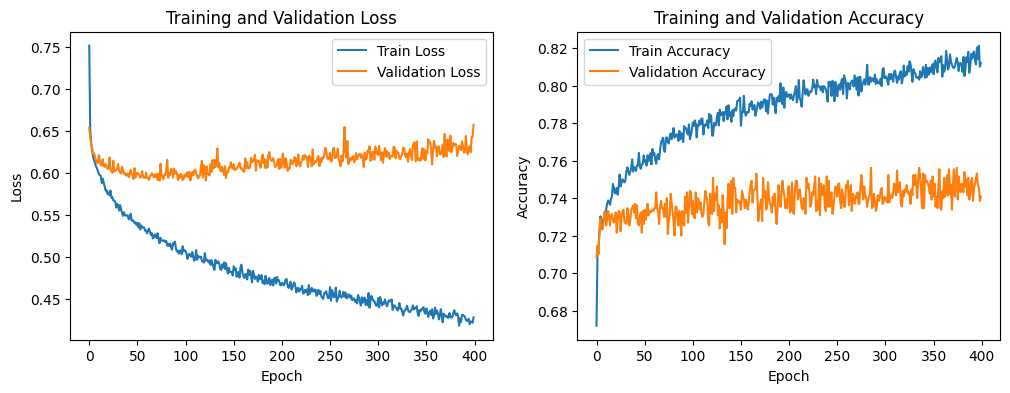

In [62]:
import matplotlib.pyplot as plt

# Визуализация на процеса на обучение
plt.figure(figsize=(12, 4))

# Загуба
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Точност
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()


Прогноза за алкохолното съдържание в виното

С линейна регресия:

Средноквадратична грешка (MSE) на тестовия набор: 0.2612082769557462


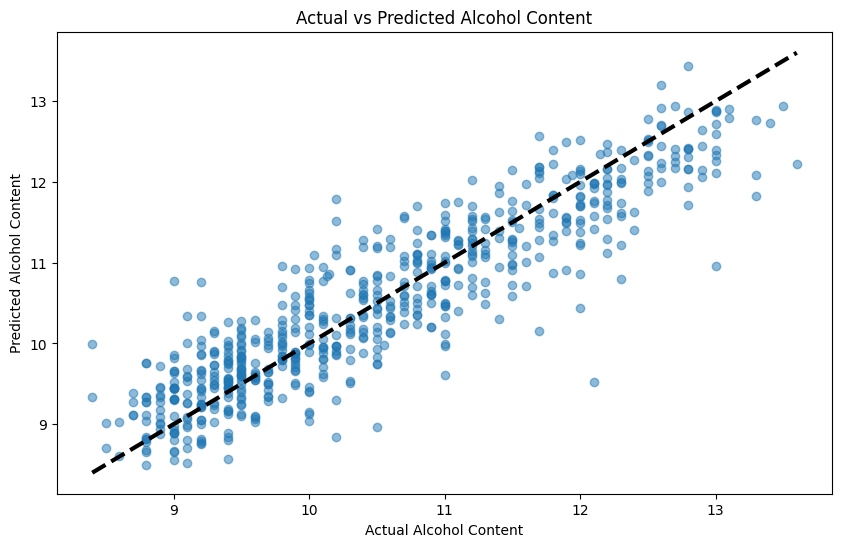

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Избиране на характеристики за предсказване на алкохолното съдържание, включително колоната 'quality'
X = wine_data.drop(['alcohol', 'color'], axis=1)
y = wine_data['alcohol']

# Полиномиални характеристики за колоната 'quality'
poly = PolynomialFeatures(degree=2, include_bias=False)
quality_poly = poly.fit_transform(wine_data[['quality']])
quality_poly_df = pd.DataFrame(quality_poly, columns=[f'quality_poly_{i}' for i in range(quality_poly.shape[1])])

# Добавяне на полиномиалните характеристики към оригиналния DataFrame
X = pd.concat([X, quality_poly_df], axis=1)

# Скалиране на данните
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяне на данните на обучаващ и тестов набор
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

# Създаване на модел за линейна регресия
linear_model = LinearRegression()

# Обучение на модела
linear_model.fit(X_train, y_train)

# Прогнозиране на алкохолното съдържание за тестовия набор
y_pred = linear_model.predict(X_test)

# Оценка на модела
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Средноквадратична грешка (MSE) на тестовия набор: {mse}")

# Визуализация на прогнозите спрямо реалните стойности
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=3)
plt.title('Actual vs Predicted Alcohol Content')
plt.xlabel('Actual Alcohol Content')
plt.ylabel('Predicted Alcohol Content')
plt.show()


С невронна мрежа

Epoch 1/1000


c:\Users\Owner\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 61.2196 - val_loss: 6.0401
Epoch 2/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 4.1005 - val_loss: 4.0276
Epoch 3/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - loss: 2.6122 - val_loss: 2.7351
Epoch 4/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 1.9437 - val_loss: 1.9391
Epoch 5/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 1.1748 - val_loss: 1.3196
Epoch 6/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - loss: 0.7848 - val_loss: 0.8250
Epoch 7/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - loss: 0.4814 - val_loss: 0.5156
Epoch 8/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - loss: 0.3427 - val_loss: 0.3692
Epoch 9/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 0.2756 - val_loss: 0.3060
Epoch 10/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - loss: 0.2336 - val_loss: 0.2822
Epoch 11/1000
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 0.2238 - val_loss: 0.2680
Epoch 12/1000
183/183 

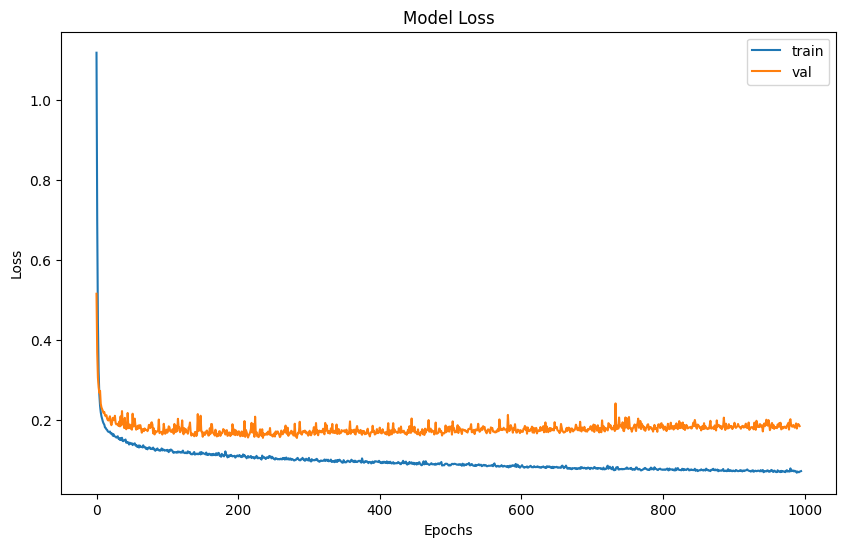

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


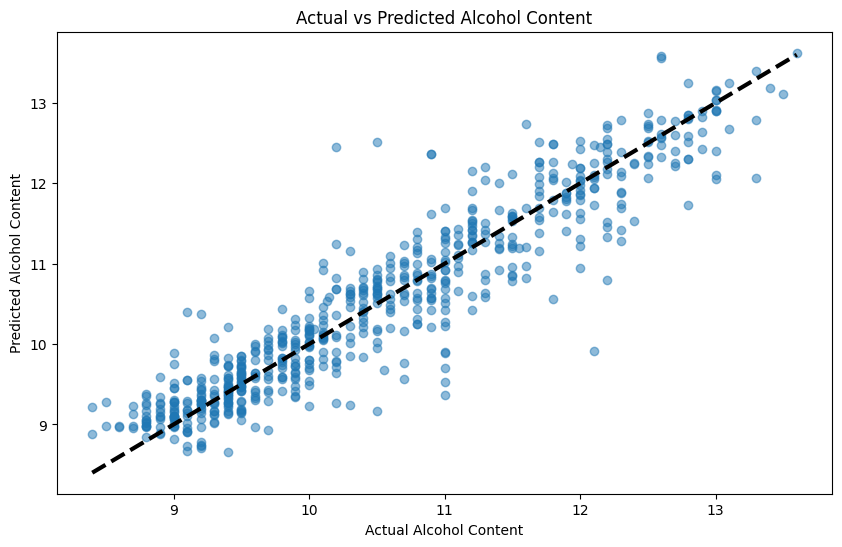

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Избиране на характеристики за предсказване на алкохолното съдържание
X = wine_data.drop(['alcohol', 'quality', 'color'], axis=1)
y = wine_data['alcohol']

# Скалиране на данните
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяне на данните на обучаващ и тестов набор
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

# Създаване на модел за невронна мрежа
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  
])

# Компилиране на модела
model.compile(optimizer=Adam(), loss=MeanSquaredError())

# Обучение на модела
history = model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Оценка на модела
mse = model.evaluate(X_test, y_test, verbose=0)
print(f"Средноквадратична грешка (MSE) на тестовия набор: {mse}")

# Визуализация на графика за загубата
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'][4:], label='train')  # започване от 5-тата епоха
plt.plot(history.history['val_loss'][6:], label='val')  # започване от 5-тата епоха
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Прогнозиране на алкохолното съдържание за тестовия набор
y_pred = model.predict(X_test)

# Визуализация на прогнозите спрямо реалните стойности
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=3)
plt.title('Actual vs Predicted Alcohol Content')
plt.xlabel('Actual Alcohol Content')
plt.ylabel('Predicted Alcohol Content')
plt.show()


Клъстеризация на база на цвета на виното

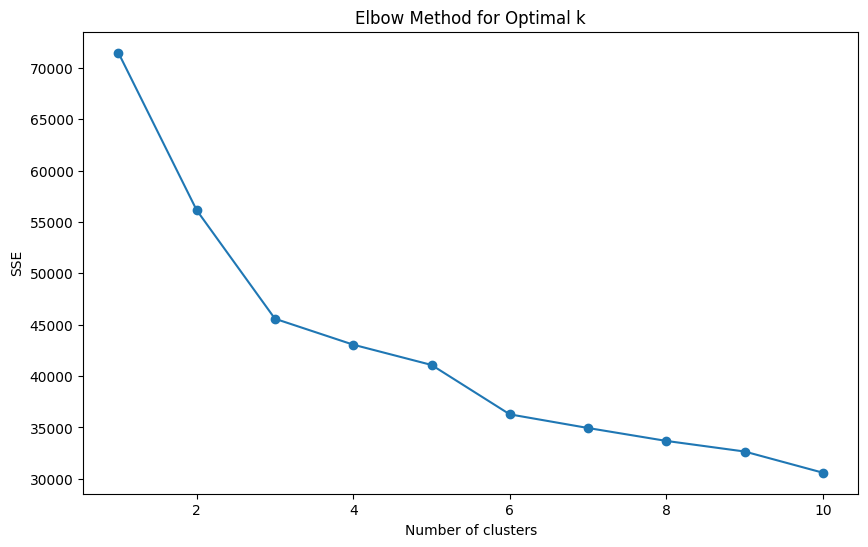

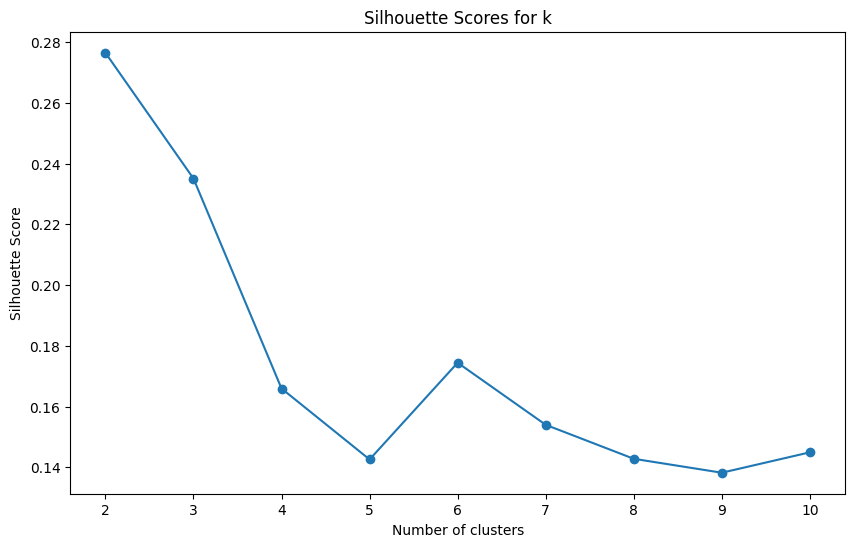

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Обединяване на данните за червено и бяло вино
wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Преобразуване на цвета в числова стойност
wine_data['color'] = wine_data['color'].map({'red': 0, 'white': 1})

# Избиране на характеристиките за клъстеризация
X = wine_data.drop(columns=['color', 'quality'])

# Скалиране на данните
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow метод за определяне на оптималния брой клъстери
sse = []
silhouette_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    if k > 1:
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Визуализация на Elbow метода
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal k')
plt.show()

# Визуализация на Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range[1:], silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for k')
plt.show()


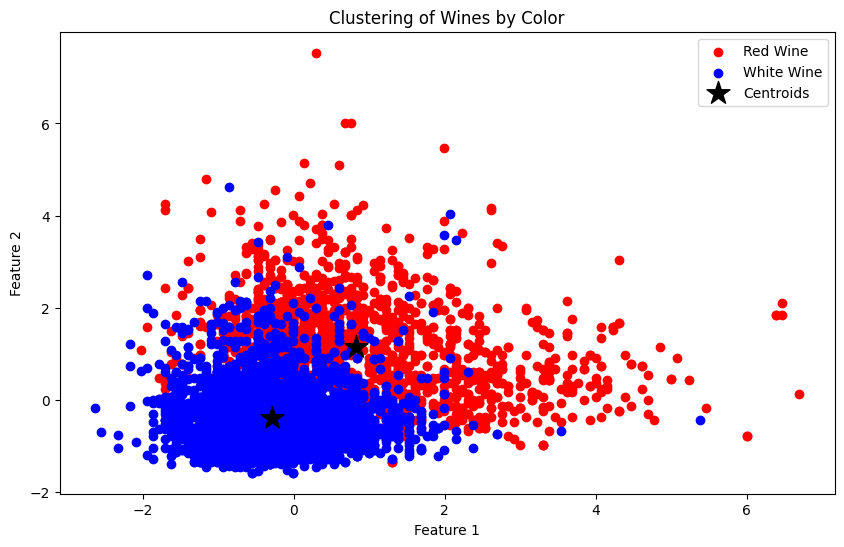

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Извличане на характеристики за клъстеризацията (без целеви колони)
X = wine_data.drop(['color'], axis=1)

# Скалиране на данните
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Клъстеризация с K-means на два клъстера
kmeans = KMeans(n_clusters=2, random_state=42)
wine_data['cluster'] = kmeans.fit_predict(X_scaled)

# Визуализация на клъстерите според цвета на виното
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[wine_data['color'] == 'red'][:, 0], X_scaled[wine_data['color'] == 'red'][:, 1], c='red', label='Red Wine')
plt.scatter(X_scaled[wine_data['color'] == 'white'][:, 0], X_scaled[wine_data['color'] == 'white'][:, 1], c='blue', label='White Wine')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='*', s=300, c='black', label='Centroids')
plt.title('Clustering of Wines by Color')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()




In [74]:
# Изчисляване на точността
# За да направим това, първо трябва да определим коя клъстерна група съответства на кой цвят
cluster_labels = kmeans.labels_
# Създаваме DataFrame за да обобщим информацията
cluster_color_df = pd.DataFrame({'color': wine_data['color'], 'cluster': cluster_labels})

# Проверка на съотношението на цветовете в двата клъстера
cluster_summary = cluster_color_df.groupby('cluster')['color'].agg(lambda x: x.mode()[0])
cluster_mapping = {0: cluster_summary[0], 1: cluster_summary[1]}

# Създаване на предсказания на базата на клъстерите
wine_data['predicted_color'] = wine_data['cluster'].map(cluster_mapping)

# Изчисляване на точността
accuracy = accuracy_score(wine_data['color'], wine_data['predicted_color'])
print(f"Точност на клъстеризацията спрямо цвета на виното: {accuracy:.2f}")

Точност на клъстеризацията спрямо цвета на виното: 0.98


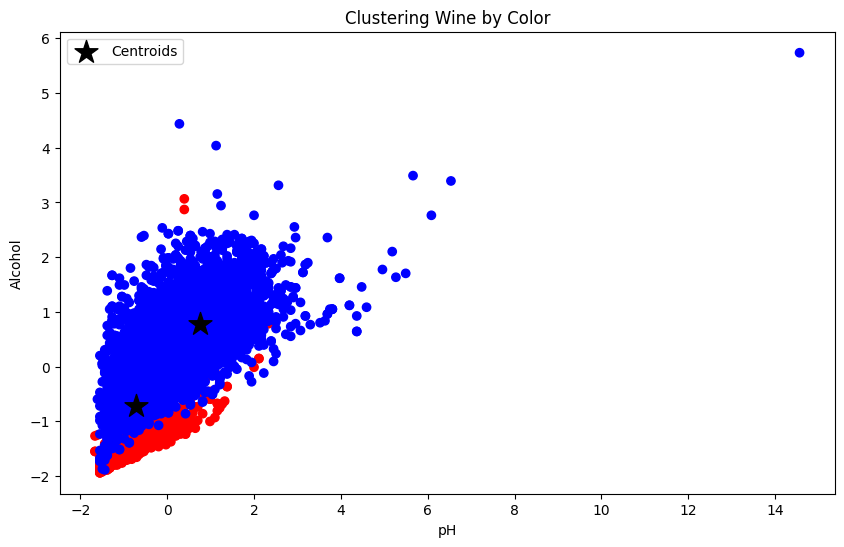

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Зареждане на данните
# Обединяване на данните за червено и бяло вино
wine_data = pd.concat([red_wine, white_wine], axis=0, ignore_index=True)

# Добавяне на колона за цвета на виното
#wine_data['color'] = wine_data.apply(lambda row: 'red' if row['type'] == 1 else 'white', axis=1)

# Избиране на характеристики за клъстеризация (например pH и алкохол)
X = wine_data[['free sulfur dioxide', 'total sulfur dioxide']]

# Скалиране на данните
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Клъстеризация с KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
wine_data['cluster'] = kmeans.fit_predict(X_scaled)

# Визуализация на клъстерите
plt.figure(figsize=(10, 6))
colors = {'red': 'red', 'white': 'blue'}
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=wine_data['color'].apply(lambda x: colors[x]))
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='*', s=300, c='black', label='Centroids')
plt.xlabel('pH')
plt.ylabel('Alcohol')
plt.title('Clustering Wine by Color')
plt.legend()
plt.show()
